# Target Tracking for Marine Vehicles

Target tracking involves guiding an interceptor craft to rendezvous with a moving target. According to Thor I. Fossen's *Guidance Systems* principles, we can utilize three primary terminal guidance laws.
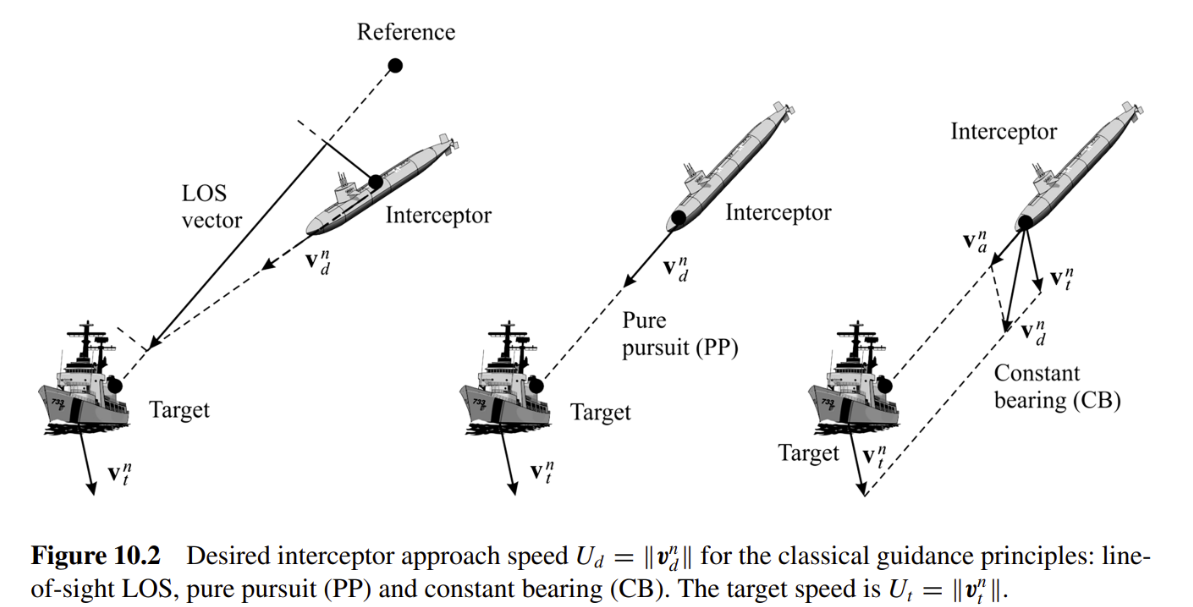

![](https://drive.google.com/uc?export=view&id=1-ZoPjeoFspXsSs_5y_mWvoRM5AjbpSik)
[Fossen, Thor I. Handbook of marine craft hydrodynamics and motion control. John wiley & sons, 2011.]

### 1. Line-of-Sight (LOS)
Line-of-Sight (or Beam Riding) is a 3-point guidance scheme. A stationary reference ($\mathbf{p}_{ref}$) shines an imaginary beam at the target ($\mathbf{p}_t$). The interceptor robot attempts to minimize its cross-track error ($e$) to ride this beam to the target.
* **Beam Angle:** $$\alpha = \text{atan2}(y_t - y_{ref}, x_t - x_{ref})$$
* **Cross-track Error:** $$e = -(x - x_{ref})\sin(\alpha) + (y - y_{ref})\cos(\alpha)$$
* **Desired Heading:** $$\psi_d = \alpha + \arctan\left(\frac{-e}{\Delta}\right)$$
where $\Delta$ is the lookahead distance shaping the approach to the beam.


### 2. Pure Pursuit (PP)
Pure Pursuit is a 2-point guidance scheme where the interceptor simply points its velocity vector directly at the target's current position, resulting in a classic "tail chase".
Given the relative position vector $\tilde{\mathbf{p}} = \mathbf{p}_{robot} - \mathbf{p}_{target}$, the desired velocity is:
$$\mathbf{v}_d = -k \frac{\tilde{\mathbf{p}}}{||\tilde{\mathbf{p}}||}$$
where $k > 0$ is the interceptor's speed.

### 3. Constant Bearing (CB)
Constant Bearing is a 2-point guidance scheme that anticipates the target's movement. It uses the target's velocity ($\mathbf{v}_t$) as a feedforward term to calculate a direct intercept course, keeping the Line-of-Sight angle constant.
$$\mathbf{v}_d = \mathbf{v}_t - \kappa \frac{\tilde{\mathbf{p}}}{||\tilde{\mathbf{p}}||}$$
where $\kappa > 0$ dictates the closing approach speed.

In [1]:

# reinitializing python configuration after installing the package
#import site
#site.main()

# A. Constant target heading

In [2]:
# -*- coding: utf-8 -*-
"""guidance_target_tracking_straight_line.ipynb
"""

import numpy as np
import matplotlib.pyplot as plt
import math
from python_vehicle_simulator.vehicles import otter
from python_vehicle_simulator.lib import attitudeEuler
import copy

def sawtooth(x):
    return 2 * np.arctan(np.tan(x / 2))

# --- 1. OTTER USV CONTROLLER ---
class myOtter(otter):
    def __init__(self, controlSystem, u_d, V_current, beta_current):
        mycontrolSystem = str(controlSystem)
        super().__init__(controlSystem, 0, V_current, beta_current, 0)
        self.D2R = np.pi / 180
        if mycontrolSystem == "my_controller":
            self.u_d = u_d
            self.a_d = 0
            self.r_d = 0
            self.e_u_int = 0
            self.e_psi_int = 0
            self.controlMode = mycontrolSystem

    def my_controller(self, eta, nu, ref, sampleTime):
        psi, r, u = eta[5], nu[5], nu[0]
        u_d, psi_d, r_d = ref[0], ref[1], ref[2]

        e_psi = sawtooth(psi - psi_d)
        e_r = r - r_d
        e_u = u - u_d

        self.e_u_int += e_u * sampleTime
        self.e_psi_int += e_psi * sampleTime

        # Tuned Gains
        Kpu, Kiu = 150., 10.
        Kpy, Kiy, Kdy = 50.0, 0.1, 20.0

        tau_X = -Kpu * e_u - Kiu * self.e_u_int
        tau_N = -Kpy * e_psi - Kiy * self.e_psi_int - Kdy * e_r

        tau = np.array([tau_X, tau_N])
        u_alloc = np.matmul(self.Binv, tau)

        n_left = np.sign(u_alloc[0]) * math.sqrt(abs(u_alloc[0]))
        n_right = np.sign(u_alloc[1]) * math.sqrt(abs(u_alloc[1]))

        return np.array([n_left, n_right], float), e_u, e_psi, 0

# --- 2. SIMULATION FUNCTION ---
def simulate_target_tracking(N, sampleTime, vehicle, guidance_method="CB"):
    DOF = 6
    eta = np.array([0, 0, 0, 0, 0, 0], float) # Start at origin (0,0)
    nu = vehicle.nu
    u_actual = vehicle.u_actual
    simData = np.empty([0, 2 * DOF + 2 * vehicle.dimU], float)
    targetData = np.empty([0, 2], float)

    Delta = 100.0 # Parameter for LOS
    kappa = 2.5 # Parameter for CB
    p_ref = np.array([0.0, 0.0]) # Reference for LOS beam
    psi_d = eta[5]

    for i in range(0, N + 1):
        t = i * sampleTime

        # ---------------------------------------------------------
        # SLOW TARGET WITH CONSTANT HEADING (Straight Line)
        # Target starts at (-100, 50) and moves NE at 0.5 m/s in both axes
        # ---------------------------------------------------------
        p_t0 = np.array([-100.0, 50.0])
        v_t = np.array([0.5, 0.5]) # Constant target velocity
        p_t = p_t0 + v_t * t       # Target position over time

        pr = np.array([eta[0], eta[1]], float)
        p_tilde = pr - p_t
        dist = np.linalg.norm(p_tilde)
        psi_old_d = psi_d

        # --- GUIDANCE LAWS ---
        if dist > 3.0: # Target has not been reached

            if guidance_method == "LOS":
                # TODO: Line-of-Sight
                psi_d = ...
                u_d = vehicle.u_d

            elif guidance_method == "PP":
                # TODO: Pure Pursuit
                psi_d = ...
                u_d = ...

            elif guidance_method == "CB":
                # TODO: Constant Bearing
                psi_d = ...
                u_d = ...

        else:
            # Target reached: Match speed and heading
            u_d = np.linalg.norm(v_t)
            psi_d = np.arctan2(v_t[1], v_t[0])

        r_d = 0.0
        z_d = vehicle.z_d if hasattr(vehicle, 'z_d') else 0

        # Apply to Controller
        ref = np.array([u_d, psi_d, r_d, z_d], float)
        u_control, e_u, e_yaw, e_z = vehicle.my_controller(eta, nu, ref, sampleTime)
        # Store data & Propagate dynamics
        signals = np.append(np.append(np.append(eta, nu), u_control), u_actual)
        simData = np.vstack([simData, signals])
        targetData = np.vstack([targetData, p_t])

        nu, u_actual = vehicle.dynamics(eta, nu, u_actual, u_control, sampleTime)
        eta = attitudeEuler(eta, nu, sampleTime)

    simTime = np.arange(start=0, stop=t + sampleTime, step=sampleTime)[:, None]
    return simTime, simData, targetData

# --- 3. RUN AND PLOT ---
sim_time = 500.0   # Simulation time
sampleTime = 0.05
N = int(sim_time / sampleTime)

otter_usv = myOtter("my_controller", u_d=0.5, V_current=0., beta_current=0.) # you can try to increase the desired speed (u_d)

# Plot
plt.figure(figsize=(10, 8))

simTime, simData_LOS, targetData = simulate_target_tracking(N, sampleTime, otter_usv, "LOS")
plt.plot(simData_LOS[:, 0], simData_LOS[:, 1], 'g-', linewidth=2, label='Line-Of-Sight')

simTime, simData_PP, targetData = simulate_target_tracking(N, sampleTime, otter_usv, "PP")
plt.plot(simData_PP[:, 0], simData_PP[:, 1], 'r-', linewidth=2, label='Pure Pursuit')

simTime, simData_CB, targetData = simulate_target_tracking(N, sampleTime, otter_usv, "CB")
plt.plot(simData_CB[:, 0], simData_CB[:, 1], 'b-', linewidth=2, label='Constant Bearing')

plt.scatter(targetData[0, 0], targetData[0, 1], c='k', marker='o', s=100, label='Target Start')
plt.scatter(0, 0, c='magenta', marker='s', s=100, label='Interceptor Start')

plt.plot(targetData[:, 0], targetData[:, 1], 'k--', linewidth=2, label='Slow Constant Target Trajectory')

plt.title("Guidance Methods vs Slow Constant-Heading Target")
plt.xlabel("X (North)")
plt.ylabel("Y (East)")
plt.legend(loc='lower right')
plt.grid(True)
plt.axis('equal')
plt.show()

TypeError: float() argument must be a string or a real number, not 'ellipsis'

<Figure size 1000x800 with 0 Axes>

## Generate animation

In [ ]:
# @title
import matplotlib.animation as animation
from IPython.display import HTML

# --- 4. ANIMATION SETUP ---
fig, ax = plt.subplots(figsize=(10, 8))

# Define Axis Limits
all_x = np.concatenate([simData_LOS[:,0], simData_PP[:,0], simData_CB[:,0], targetData[:,0]])
all_y = np.concatenate([simData_LOS[:,1], simData_PP[:,1], simData_CB[:,1], targetData[:,1]])
ax.set_xlim(np.min(all_x) - 10, np.max(all_x) + 10)
ax.set_ylim(np.min(all_y) - 10, np.max(all_y) + 10)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.set_aspect('equal')

# Static elements
ax.scatter(targetData[0, 0], targetData[0, 1], c='k', marker='o', s=100, label='Target Start')
ax.scatter(0, 0, c='magenta', marker='s', s=100, label='Interceptor Start')

# Dynamic lines
line_los, = ax.plot([], [], 'g-', linewidth=2, label='Line-Of-Sight')
line_pp,  = ax.plot([], [], 'r-', linewidth=2, label='Pure Pursuit')
line_cb,  = ax.plot([], [], 'b-', linewidth=2, label='Constant Bearing')
line_tgt, = ax.plot([], [], 'k--', linewidth=2, label='Target Trajectory')

# Dynamic points representing current positions
pt_los, = ax.plot([], [], 'go', markersize=8)
pt_pp,  = ax.plot([], [], 'ro', markersize=8)
pt_cb,  = ax.plot([], [], 'bo', markersize=8)
pt_tgt, = ax.plot([], [], 'ko', markersize=8)

ax.legend(loc='lower right')

# Animation Update Function
frame_step = 100 # Adjust this to make animation render faster/slower
frames = range(0, len(targetData), frame_step)

def update(frame):
    # Update trail lines
    line_los.set_data(simData_LOS[:frame, 0], simData_LOS[:frame, 1])
    line_pp.set_data(simData_PP[:frame, 0], simData_PP[:frame, 1])
    line_cb.set_data(simData_CB[:frame, 0], simData_CB[:frame, 1])
    line_tgt.set_data(targetData[:frame, 0], targetData[:frame, 1])

    # Update head markers (Note: set_data requires sequences, so we wrap in [])
    pt_los.set_data([simData_LOS[frame, 0]], [simData_LOS[frame, 1]])
    pt_pp.set_data([simData_PP[frame, 0]], [simData_PP[frame, 1]])
    pt_cb.set_data([simData_CB[frame, 0]], [simData_CB[frame, 1]])
    pt_tgt.set_data([targetData[frame, 0]], [targetData[frame, 1]])

    return line_los, line_pp, line_cb, line_tgt, pt_los, pt_pp, pt_cb, pt_tgt

ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

# Close the figure so the static frame doesn't render alongside the animation
plt.close(fig)
HTML(ani.to_jshtml())

NameError: name 'plt' is not defined

# B. Highly maneuverable / agile target

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from python_vehicle_simulator.vehicles import otter
from python_vehicle_simulator.lib import attitudeEuler
import copy

def sawtooth(x):
    return 2 * np.arctan(np.tan(x / 2))

# --- 1. OTTER USV CONTROLLER ---
class myOtter(otter):
    def __init__(self, controlSystem, u_d, V_current, beta_current):
        mycontrolSystem = str(controlSystem)
        super().__init__(controlSystem, 0, V_current, beta_current, 0)
        self.D2R = np.pi / 180
        if mycontrolSystem == "my_controller":
            self.u_d = u_d
            self.a_d = 0
            self.r_d = 0
            self.e_u_int = 0
            self.e_psi_int = 0
            self.controlMode = mycontrolSystem

    def my_controller(self, eta, nu, ref, sampleTime):
        psi, r, u = eta[5], nu[5], nu[0]
        u_d, psi_d, r_d = ref[0], ref[1], ref[2]

        e_psi = sawtooth(psi - psi_d)
        e_r = r - r_d
        e_u = u - u_d

        self.e_u_int += e_u * sampleTime
        self.e_psi_int += e_psi * sampleTime

        # Tuned Gains
        Kpu, Kiu = 150., 10.
        Kpy, Kiy, Kdy = 50.0, 0.1, 20.0

        tau_X = -Kpu * e_u - Kiu * self.e_u_int
        tau_N = -Kpy * e_psi - Kiy * self.e_psi_int - Kdy * e_r

        tau = np.array([tau_X, tau_N])
        u_alloc = np.matmul(self.Binv, tau)

        n_left = np.sign(u_alloc[0]) * math.sqrt(abs(u_alloc[0]))
        n_right = np.sign(u_alloc[1]) * math.sqrt(abs(u_alloc[1]))

        return np.array([n_left, n_right], float), e_u, e_psi, 0

# --- 2. SIMULATION FUNCTION ---
def simulate_target_tracking(N, sampleTime, vehicle, guidance_method="CB"):
    DOF = 6
    eta = np.array([0, 0, 0, 0, 0, 0], float) # Start at origin (0,0)
    nu = vehicle.nu
    u_actual = vehicle.u_actual
    simData = np.empty([0, 2 * DOF + 2 * vehicle.dimU], float)
    targetData = np.empty([0, 4], float)

    Delta = 1000.0 # Parameter for LOS
    kappa = 2.5 # Parameter for CB
    p_ref = np.array([0.0, 0.0]) # Reference for LOS beam
    psi_d = eta[5]

    for i in range(0, N + 1):
        t = i * sampleTime

        # Agile Target Generation
        freq_x = 1.0/80
        freq_y = 1.0/40
        p_t = np.array([20 + 60 * np.sin(freq_x * t), 50 + 40 * np.sin(freq_y * t)])
        v_t = np.array([60 * freq_x * np.cos(freq_x * t), 40 * freq_y * np.cos(freq_y * t)])

        pr = np.array([eta[0], eta[1]], float)
        p_tilde = pr - p_t
        dist = np.linalg.norm(p_tilde)
        psi_old_d = psi_d

        # --- GUIDANCE LAWS ---
        if dist > 3.0:
            if guidance_method == "LOS":
                # TODO: Line-of-Sight
                psi_d = ...
                u_d = vehicle.u_d

            elif guidance_method == "PP":
                # TODO: Pure Pursuit
                psi_d = ...
                u_d = ...

            elif guidance_method == "CB":
                # TODO: Constant Bearing
                psi_d = ...
                u_d = ...

        else:
            # Target reached: Match speed and heading
            u_d = np.linalg.norm(v_t)
            psi_d = np.arctan2(v_t[1], v_t[0])

        r_d = 0.0
        z_d = vehicle.z_d if hasattr(vehicle, 'z_d') else 0

        # Apply to Controller
        ref = np.array([u_d, psi_d, r_d, z_d], float)
        u_control, e_u, e_yaw, e_z = vehicle.my_controller(eta, nu, ref, sampleTime)
        # Store data & Propagate dynamics
        signals = np.append(np.append(np.append(eta, nu), u_control), u_actual)
        simData = np.vstack([simData, signals])
        target_state = np.append(p_t, v_t)
        targetData = np.vstack([targetData, target_state])

        nu, u_actual = vehicle.dynamics(eta, nu, u_actual, u_control, sampleTime)
        eta = attitudeEuler(eta, nu, sampleTime)

    simTime = np.arange(start=0, stop=t + sampleTime, step=sampleTime)[:, None]
    return simTime, simData, targetData

# --- 3. RUN AND PLOT ---
sim_time = 500.0   # Simulation time
sampleTime = 0.05
N = int(sim_time / sampleTime)

otter_usv = myOtter("my_controller", u_d=0.7, V_current=0., beta_current=0.) # you can try to increase the desired speed (u_d)

# Plot
plt.figure(figsize=(10, 8))

simTime, simData_CB, targetData = simulate_target_tracking(N, sampleTime, otter_usv, "CB")
plt.plot(simData_CB[:, 0], simData_CB[:, 1], 'b-', linewidth=2, label='Constant Bearing (Direct Intercept)')

simTime, simData_PP, targetData = simulate_target_tracking(N, sampleTime, otter_usv, "PP")
plt.plot(simData_PP[:, 0], simData_PP[:, 1], 'r-', linewidth=2, label='Pure Pursuit (Pursuit Curve)')

simTime, simData_LOS, targetData = simulate_target_tracking(N, sampleTime, otter_usv, "LOS")
plt.plot(simData_LOS[:, 0], simData_LOS[:, 1], 'g-', linewidth=2, label='Line-Of-Sight (Beam Rider)')

plt.scatter(targetData[0, 0], targetData[0, 1], c='k', marker='o', s=100, label='Target Start')
plt.scatter(0, 0, c='magenta', marker='s', s=100, label='Interceptor Start')

plt.plot(targetData[:, 0], targetData[:, 1], 'k--', linewidth=2, label='Slow Constant Target Trajectory')

plt.title("Guidance Methods vs Slow Constant-Heading Target")
plt.xlabel("X (North)")
plt.ylabel("Y (East)")
plt.legend(loc='lower right')
plt.grid(True)
plt.axis('equal')
plt.show()

## Generate animation

In [ ]:
# @title
import matplotlib.animation as animation
from IPython.display import HTML

# --- 4. ANIMATION SETUP ---
fig, ax = plt.subplots(figsize=(10, 8))

# Define Axis Limits
all_x = np.concatenate([simData_LOS[:,0], simData_PP[:,0], simData_CB[:,0], targetData[:,0]])
all_y = np.concatenate([simData_LOS[:,1], simData_PP[:,1], simData_CB[:,1], targetData[:,1]])
ax.set_xlim(np.min(all_x) - 10, np.max(all_x) + 10)
ax.set_ylim(np.min(all_y) - 10, np.max(all_y) + 10)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.set_aspect('equal')

# Static elements
ax.scatter(targetData[0, 0], targetData[0, 1], c='k', marker='o', s=100, label='Target Start')
ax.scatter(0, 0, c='magenta', marker='s', s=100, label='Interceptor Start')

# Dynamic lines
line_los, = ax.plot([], [], 'g-', linewidth=2, label='Line-Of-Sight')
line_pp,  = ax.plot([], [], 'r-', linewidth=2, label='Pure Pursuit')
line_cb,  = ax.plot([], [], 'b-', linewidth=2, label='Constant Bearing')
line_tgt, = ax.plot([], [], 'k--', linewidth=2, label='Target Trajectory')

# Dynamic points representing current positions
pt_los, = ax.plot([], [], 'go', markersize=8)
pt_pp,  = ax.plot([], [], 'ro', markersize=8)
pt_cb,  = ax.plot([], [], 'bo', markersize=8)
pt_tgt, = ax.plot([], [], 'ko', markersize=8)

ax.legend(loc='lower right')

# Animation Update Function
frame_step = 100 # Adjust this to make animation render faster/slower
frames = range(0, len(targetData), frame_step)

def update(frame):
    # Update trail lines
    line_los.set_data(simData_LOS[:frame, 0], simData_LOS[:frame, 1])
    line_pp.set_data(simData_PP[:frame, 0], simData_PP[:frame, 1])
    line_cb.set_data(simData_CB[:frame, 0], simData_CB[:frame, 1])
    line_tgt.set_data(targetData[:frame, 0], targetData[:frame, 1])

    # Update head markers (Note: set_data requires sequences, so we wrap in [])
    pt_los.set_data([simData_LOS[frame, 0]], [simData_LOS[frame, 1]])
    pt_pp.set_data([simData_PP[frame, 0]], [simData_PP[frame, 1]])
    pt_cb.set_data([simData_CB[frame, 0]], [simData_CB[frame, 1]])
    pt_tgt.set_data([targetData[frame, 0]], [targetData[frame, 1]])

    return line_los, line_pp, line_cb, line_tgt, pt_los, pt_pp, pt_cb, pt_tgt

ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

# Close the figure so the static frame doesn't render alongside the animation
plt.close(fig)
HTML(ani.to_jshtml())

## Analysis
#### 1. Which strategy is the closest to reach the target?
#### 2. For LOS and CB, what will happen if you increase or decrease the parameter?
- Parameter for LOS is `Delta`
- Parameter for CB is `kappa`
#### 3. What will happen if the desired speed is changed?
- change the desired speed (`u_d`). In the code, find: `otter_usv = myOtter("my_controller", u_d=0.7, V_current=0., beta_current=0.)`
- you can also add the velocity current by changing `V_current` (the current magnitude) and `beta_current` (the current direction  [in degree]) values.

##### Note: `simData_<method>` has 16 elements per time `[eta,nu,u_actual,u_control]` with `len(eta)=6`, `len(nu)=6`, `len(u_actual)=2`, `len(u_control)=2`
##### `eta` = [position x, position y, position z, orientation roll, orientation pitch, orientation yaw]
##### `nu` = [surge velocity, sway velocity, heave velocity, angular velocity roll,  angular velocity pitch, angular velocity yaw]

Target tracking involves guiding an interceptor craft to rendezvous with a moving target.
Challenges:

In this session, you need to implement three different guidance strategies to pursue the target.
Analyze/compare different strategies:

Which strategy is the closest to reach the target?
For LOS and CB guidance, what will happen if you increase or decrease the parameters?
What will happen if the desired speed is changed?
Optional: Try scenario with heavy current



UPDATE:
In the notebook, the LOS reference is the same as the initial position of the interceptor so that it is similar with pure pursuit strategy.

eta = np.array([0, 0, 0, 0, 0, 0], float) # Start at origin (0,0)
p_ref = np.array([0.0, 0.0]) # Reference for LOS beam

To simulate the LOS guidance correctly, you can change either the initial position of interceptor or the LOS reference.

notebook for target tracking



In [ ]:
# TODO: write your code here to answer the questions above
# for example, plot the distance between the target and interceptor over time